# Student Performance Prediction

This notebook builds a machine learning workflow for predicting whether a student will pass or not based on academic and background-related features.

The project covers the full process from data exploration to model training and saving a final pipeline that can later be used inside a FastAPI application.

In [38]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

## 1. Load the Dataset

The dataset is loaded from a CSV file into a pandas DataFrame.  
The first few rows are displayed to understand the structure of the data and check the column names.

In [39]:
df = pd.read_csv(r"student_performance_prediction.csv")
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.5,NaN,75.0,Yes,Master,Yes
1,S00002,9.3,95.3,60.6,No,High School,No
2,S00003,13.2,NaN,64.0,No,Associate,No
3,S00004,17.6,76.8,62.4,Yes,Bachelor,No
4,S00005,8.8,89.3,72.7,No,Master,No


## 2. Initial Data Overview

This step gives a quick statistical summary of both numerical and categorical columns.

It helps identify:
- missing values
- unusual minimum or maximum values
- the most frequent categorical values
- the general distribution of the dataset

In [40]:
df.describe(include="all")

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
count,40000,38005.000000,38008.000000,38006.000000,38000,38000,38000
unique,40000,NaN,NaN,NaN,2,5,2
top,S00001,NaN,NaN,NaN,No,Bachelor,Yes
freq,1,NaN,NaN,NaN,19028,7685,19011
mean,NaN,9.962744,75.276323,65.440107,NaN,NaN,NaN
std,NaN,5.031154,20.393418,16.503119,NaN,NaN,NaN
min,NaN,-12.300000,-14.300000,8.300000,NaN,NaN,NaN
25%,NaN,6.600000,61.600000,55.100000,NaN,NaN,NaN
50%,NaN,10.000000,75.300000,65.200000,NaN,NaN,NaN
75%,NaN,13.400000,88.800000,75.200000,NaN,NaN,NaN


## 3. Data Types and Non-Null Counts

`df.info()` is used to check the data types of each column and the number of non-null values.

This is useful before cleaning because it shows which columns contain missing values and whether each column is stored using the expected data type.

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Student ID                                   40000 non-null  str    
 1   Study Hours per Week                         38005 non-null  float64
 2   Attendance Rate                              38008 non-null  float64
 3   Previous Grades                              38006 non-null  float64
 4   Participation in Extracurricular Activities  38000 non-null  str    
 5   Parent Education Level                       38000 non-null  str    
 6   Passed                                       38000 non-null  str    
dtypes: float64(3), str(4)
memory usage: 2.1 MB


## 4. Missing Values, Duplicates, and ID Column

Before building a model, I check for missing values and duplicated rows.

`Student ID` is removed because it is only an identifier. It does not describe the student's performance and should not be used as a model feature.

In [42]:
print(df.isnull().sum())
print(df.duplicated().sum())
df.drop("Student ID", axis=1, inplace=True)

Student ID                                        0
Study Hours per Week                           1995
Attendance Rate                                1992
Previous Grades                                1994
Participation in Extracurricular Activities    2000
Parent Education Level                         2000
Passed                                         2000
dtype: int64
0


## 5. Remove Rows with Missing Target Values

The target column is `Passed`.  
Rows where the target value is missing cannot be used for supervised learning because the model would not know the correct answer for those examples.

In [43]:
df.dropna(subset=["Passed"], inplace=True)
df.isnull().sum()

Study Hours per Week                           1905
Attendance Rate                                1888
Previous Grades                                1877
Participation in Extracurricular Activities    1902
Parent Education Level                         1898
Passed                                            0
dtype: int64

## 6. Clean Invalid Numerical Values

Some numerical values are not realistic, such as negative study hours, attendance rates below 0, attendance rates above 100, or grades above 100.

These invalid values are converted to `NaN` so they can be handled later using imputation.

In [44]:
df.loc[df["Study Hours per Week"] < 0, "Study Hours per Week"] = np.nan

df.loc[
    (df
["Attendance Rate"] < 0) | (df
["Attendance Rate"] > 100),
    "Attendance Rate"
] = np.nan

df.loc[
    (df
["Previous Grades"] < 0) | (df
["Previous Grades"] > 100),
    "Previous Grades"
] = np.nan

## 7. Target Distribution

This step checks how many students passed and how many did not.

Looking at the target distribution is important because a highly imbalanced target can make accuracy misleading.

Passed
Yes    19011
No     18989
Name: count, dtype: int64


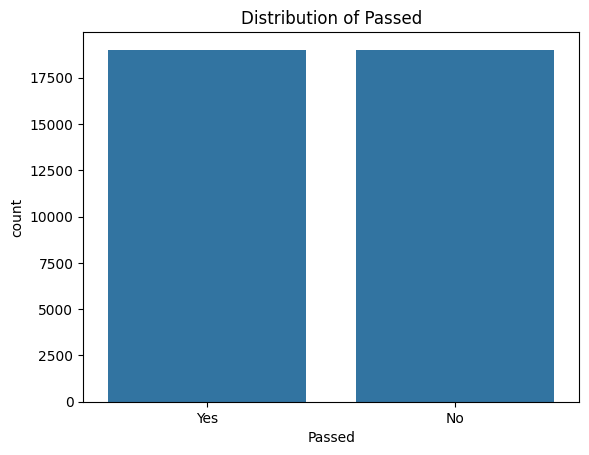

In [45]:
print(df["Passed"].value_counts(dropna=False))

sns.countplot(data=df, x="Passed")
plt.title("Distribution of Passed")
plt.show()

## 8. Numerical Feature Exploration

Histograms and boxplots are used to understand the numerical columns.

The histograms show the shape of each distribution, while the boxplots make it easier to spot possible outliers.

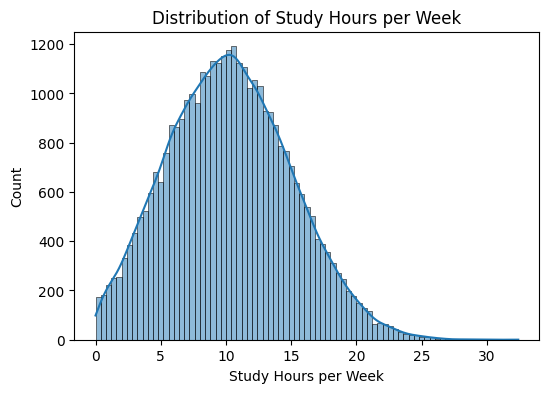

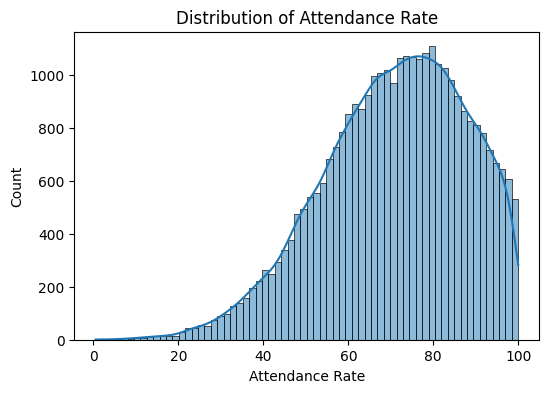

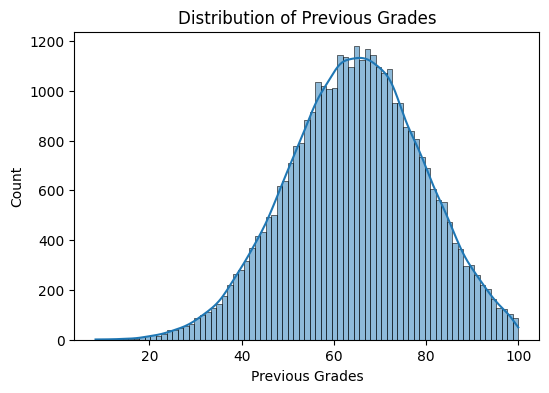

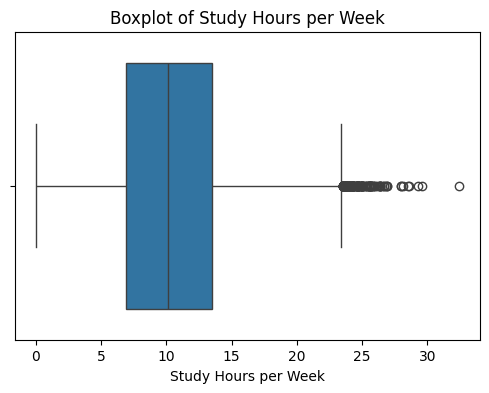

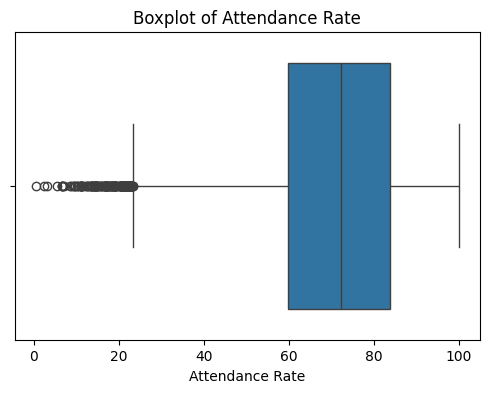

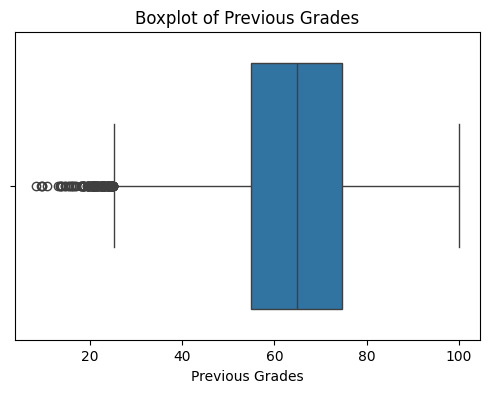

In [46]:
num_cols = ["Study Hours per Week", "Attendance Rate", "Previous Grades"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## 9. Categorical Feature Exploration

The categorical columns are checked using value counts and count plots.

This helps confirm the available categories and whether any category is much more common than the others.


Value counts for Participation in Extracurricular Activities:
Participation in Extracurricular Activities
No     18066
Yes    18032
NaN     1902
Name: count, dtype: int64


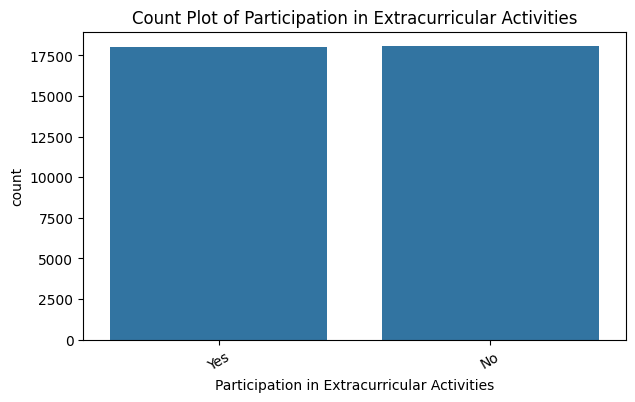


Value counts for Parent Education Level:
Parent Education Level
Bachelor       7290
High School    7264
Doctorate      7250
Associate      7241
Master         7057
NaN            1898
Name: count, dtype: int64


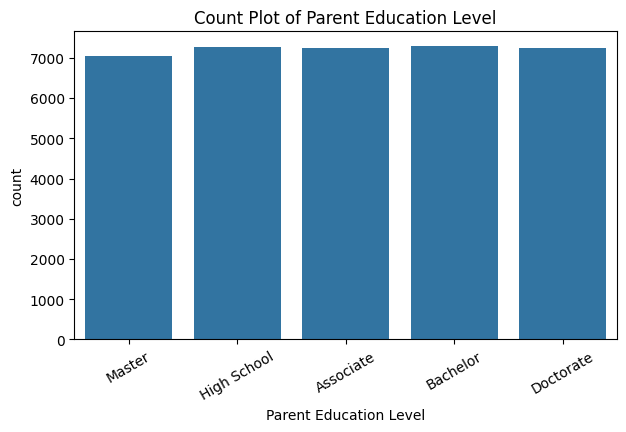

In [47]:
cat_cols = ["Participation in Extracurricular Activities", "Parent Education Level"]

for col in cat_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False))
    
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=30)
    plt.show()

## 10. Relationship Between Features and Target

At this point, I compare the features with the target column.

For numerical features, the distributions are compared across `Passed` classes.  
For categorical features, percentage tables are used instead of only raw counts, because percentages make the comparison fairer between categories.

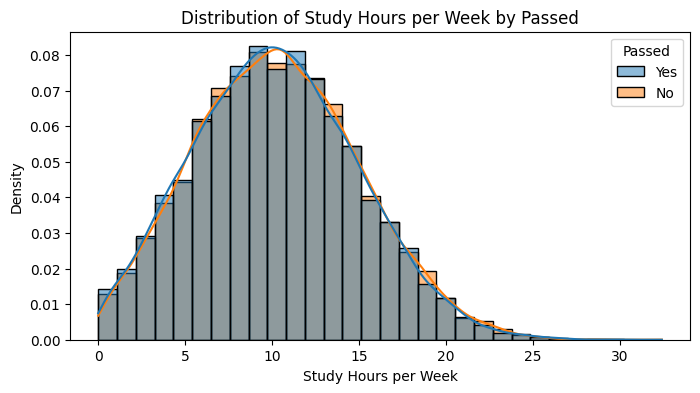

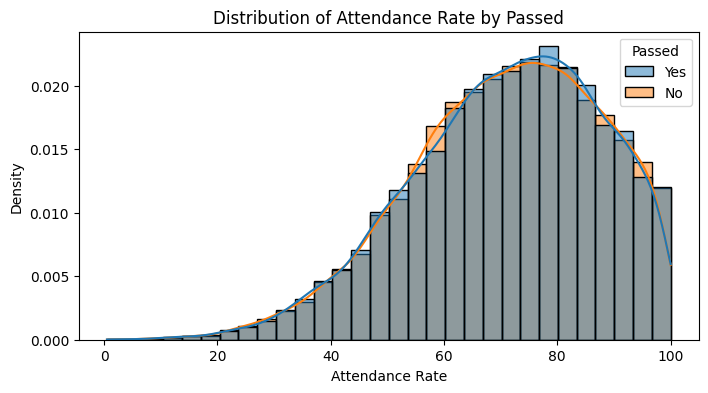

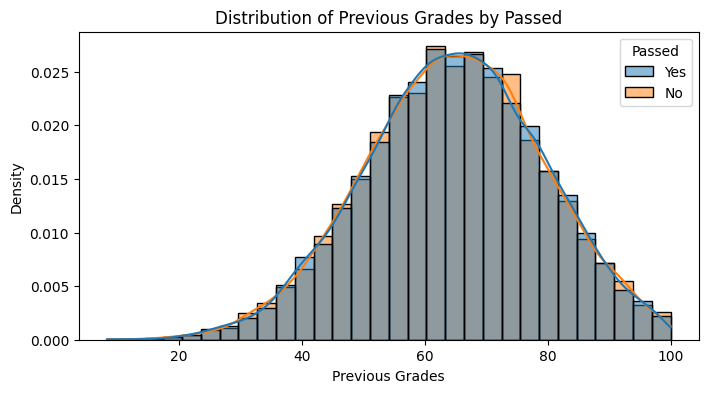


Pass percentage by Participation in Extracurricular Activities:


Passed,No,Yes
Participation in Extracurricular Activities,,
No,50.099635,49.900365
Yes,49.961180,50.038820


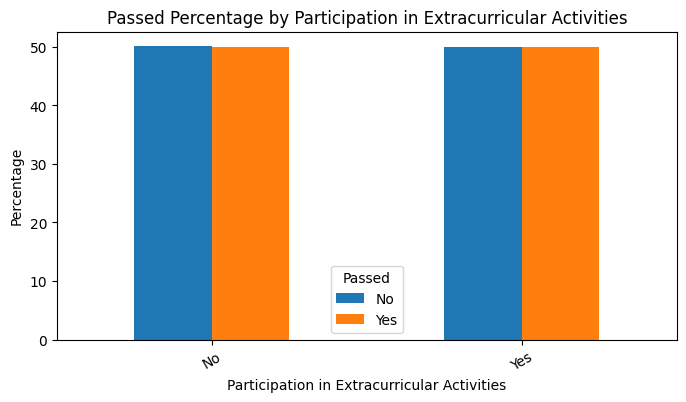


Pass percentage by Parent Education Level:


Passed,No,Yes
Parent Education Level,,
Associate,50.766469,49.233531
Bachelor,49.849108,50.150892
Doctorate,49.200000,50.800000
High School,49.848568,50.151432
Master,50.304662,49.695338


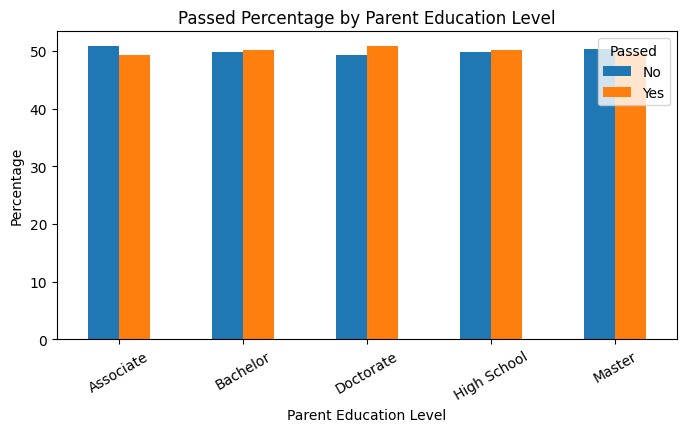

In [48]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(
        data=df,
        x=col,
        hue="Passed",
        kde=True,
        bins=30,
        stat="density",
        common_norm=False
    )
    plt.title(f"Distribution of {col} by Passed")
    plt.show()

for col in cat_cols:
    percentage_table = pd.crosstab(
        df[col],
        df["Passed"],
        normalize="index"
    ) * 100

    print(f"\nPass percentage by {col}:")
    display(percentage_table)

    percentage_table.plot(kind="bar", figsize=(8, 4))
    plt.title(f"Passed Percentage by {col}")
    plt.ylabel("Percentage")
    plt.xticks(rotation=30)
    plt.show()

## 11. Missing Value Handling for EDA

For this exploratory version of the dataset, missing numerical values are filled using the median, and missing categorical values are filled using the most frequent value.

This prepares the data for correlation analysis and manual model experiments.

In [49]:
num_cols = ["Study Hours per Week", "Attendance Rate", "Previous Grades"]
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = ["Participation in Extracurricular Activities", "Parent Education Level"]
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

## 12. Encoding Categorical Variables

Machine learning models need numerical input, so categorical columns are converted into numbers.

`Passed` is encoded as the target variable:
- `No` → 0
- `Yes` → 1

The parent education level is encoded in an ordered way because the categories have a natural ranking.

In [50]:
df["Participation in Extracurricular Activities"] = df["Participation in Extracurricular Activities"].map({
    "Yes": 1,
    "No": 0
})

df["Passed"] = df["Passed"].map({
    "Yes": 1,
    "No": 0
})

education_order = {
    "High School": 0,
    "Associate": 1,
    "Bachelor": 2,
    "Master": 3,
    "Doctorate": 4
}

df["Parent Education Level"] = df["Parent Education Level"].map(education_order)

df.head()

,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,12.5,72.4,75.0,1,3,1
1,9.3,95.3,60.6,0,0,0
2,13.2,72.4,64.0,0,1,0
3,17.6,76.8,62.4,1,2,0
4,8.8,89.3,72.7,0,3,0


## 13. Final Check After Cleaning and Encoding

Before modeling, I check the final shape, data types, and missing values.

This makes sure the dataset is ready for analysis and model training.

In [51]:
print("Final shape:", df.shape)
print("\nFinal data types:")
print(df.dtypes)

print("\nMissing values in final dataset:")
print(df.isnull().sum())

df.head()

Final shape: (38000, 6)

Final data types:
Study Hours per Week                           float64
Attendance Rate                                float64
Previous Grades                                float64
Participation in Extracurricular Activities      int64
Parent Education Level                           int64
Passed                                           int64
dtype: object

Missing values in final dataset:
Study Hours per Week                           0
Attendance Rate                                0
Previous Grades                                0
Participation in Extracurricular Activities    0
Parent Education Level                         0
Passed                                         0
dtype: int64


,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,12.5,72.4,75.0,1,3,1
1,9.3,95.3,60.6,0,0,0
2,13.2,72.4,64.0,0,1,0
3,17.6,76.8,62.4,1,2,0
4,8.8,89.3,72.7,0,3,0


## 14. Correlation Matrix

The correlation matrix shows the linear relationship between numerical columns.

In this dataset, most correlations with the target are weak. This suggests that the available features may not contain a strong linear signal for predicting whether a student passed.

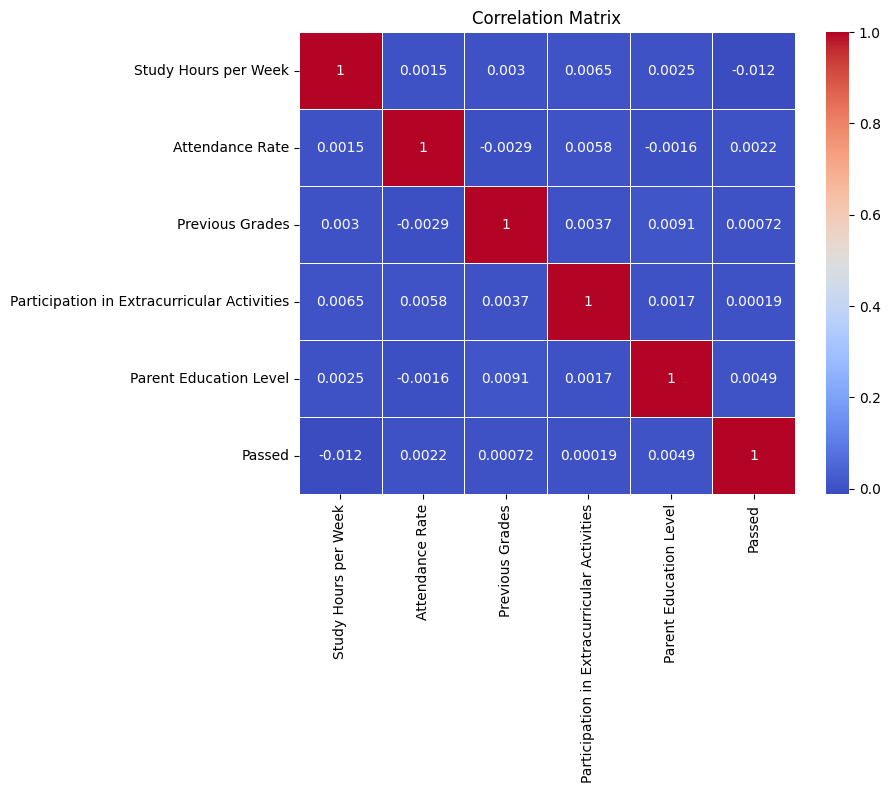

In [52]:
plt.figure(figsize=(8, 6))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

## 15. Train/Test Split and Scaling

The data is split into training and testing sets.

Scaling is applied to the numerical columns for Logistic Regression because linear models are sensitive to feature scale.  
The scaler is fitted only on the training data to avoid data leakage.

In [53]:
X = df.drop("Passed", axis=1)
y = df["Passed"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

num_cols = [
    "Study Hours per Week",
    "Attendance Rate",
    "Previous Grades"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

## 16. Model 1: Logistic Regression

Logistic Regression is used as the first baseline model.

It is a simple linear classification model, so it is a good starting point before trying more complex models.

In [54]:
model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

### Logistic Regression Confusion Matrix

The confusion matrix shows where the model is making correct and incorrect predictions for both classes.

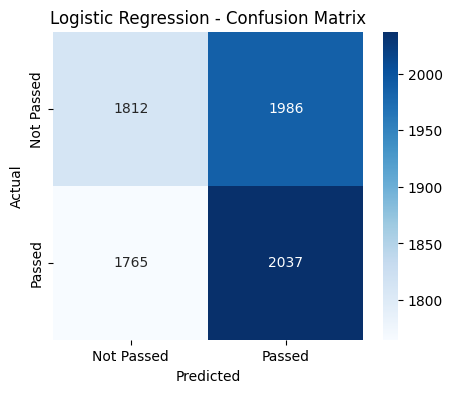

In [55]:
cm_log = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Passed", "Passed"],
    yticklabels=["Not Passed", "Passed"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Logistic Regression Evaluation

Accuracy, ROC AUC, and the classification report are used to evaluate the model.

ROC AUC is especially useful here because it shows whether the model can separate the two classes better than random guessing.

In [56]:
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Results
Accuracy: 0.5064473684210526
ROC AUC: 0.5055416912857871

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.48      0.49      3798
           1       0.51      0.54      0.52      3802

    accuracy                           0.51      7600
   macro avg       0.51      0.51      0.51      7600
weighted avg       0.51      0.51      0.51      7600



## 17. Model 2: Decision Tree

A Decision Tree is tested after Logistic Regression because it can capture non-linear patterns.

Unlike Logistic Regression, it does not require scaled features.

In [57]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

### Decision Tree Confusion Matrix

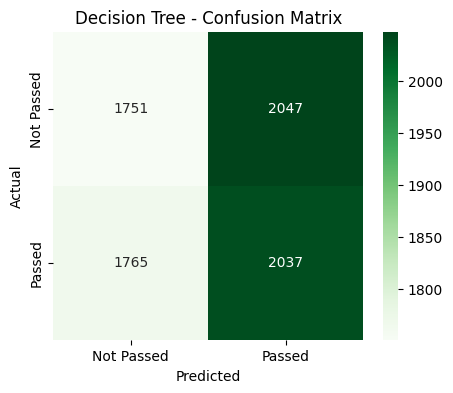

In [58]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Not Passed", "Passed"],
    yticklabels=["Not Passed", "Passed"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Decision Tree Evaluation

In [59]:
print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC AUC:", roc_auc_score(y_test, y_proba_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 0.49842105263157893
ROC AUC: 0.4977607680777752

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.46      0.48      3798
           1       0.50      0.54      0.52      3802

    accuracy                           0.50      7600
   macro avg       0.50      0.50      0.50      7600
weighted avg       0.50      0.50      0.50      7600



## 18. Model 3: Random Forest

Random Forest is an ensemble model that combines multiple decision trees.

It usually performs better than a single decision tree because it reduces overfitting and gives more stable predictions.

In [60]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

### Random Forest Confusion Matrix

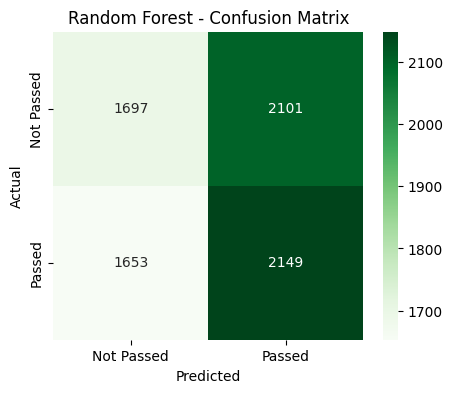

In [61]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Not Passed", "Passed"],
    yticklabels=["Not Passed", "Passed"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Random Forest Evaluation

In [62]:
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.5060526315789474
ROC AUC: 0.5011115307788174

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.45      0.47      3798
           1       0.51      0.57      0.53      3802

    accuracy                           0.51      7600
   macro avg       0.51      0.51      0.50      7600
weighted avg       0.51      0.51      0.50      7600



## 19. Model 4: XGBoost

XGBoost is a powerful boosting model based on decision trees.

It is included to test whether a stronger model can find useful patterns that simpler models missed.

In [63]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

### XGBoost Confusion Matrix

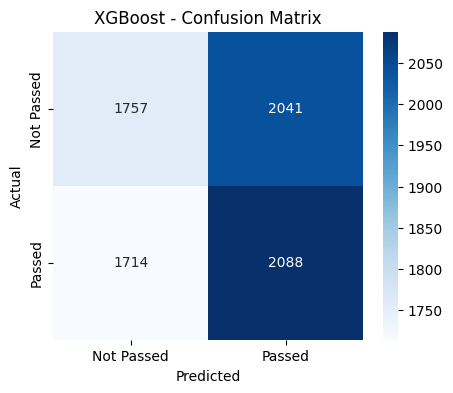

In [64]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Passed", "Passed"],
    yticklabels=["Not Passed", "Passed"]
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### XGBoost Evaluation

In [65]:
print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results
Accuracy: 0.5059210526315789
ROC AUC: 0.501330471282679

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.46      0.48      3798
           1       0.51      0.55      0.53      3802

    accuracy                           0.51      7600
   macro avg       0.51      0.51      0.50      7600
weighted avg       0.51      0.51      0.50      7600



## 20. Model Comparison

The results from all models are collected in one table.

This makes it easier to compare the models using the same metrics instead of looking at each model separately.

In [66]:
models_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    
    "ROC AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_proba_dt),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb)
    ]
})

models_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.506447,0.506339,0.535771,0.520639,0.505542
1,Decision Tree,0.498421,0.498776,0.535771,0.516612,0.497761
2,Random Forest,0.506053,0.505647,0.565229,0.533780,0.501112
3,XGBoost,0.505921,0.505691,0.549185,0.526541,0.501330


### ROC AUC Comparison

This plot compares the models using ROC AUC.

Since the ROC AUC scores are close to 0.50, the models are performing close to random guessing. This indicates that the current features are not strongly predictive of the target.

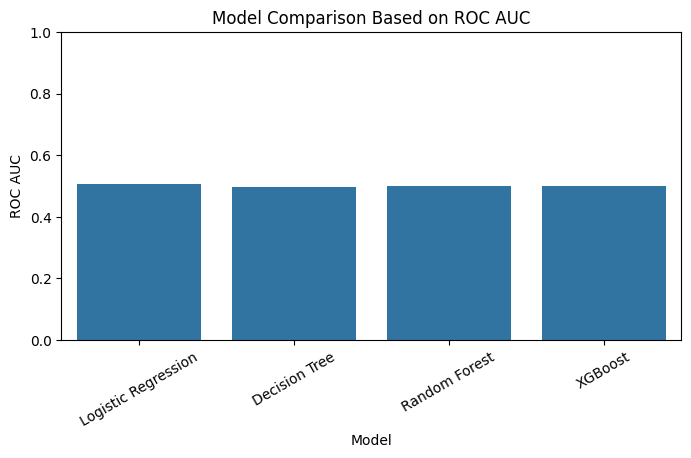

In [67]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=models_results,
    x="Model",
    y="ROC AUC"
)

plt.title("Model Comparison Based on ROC AUC")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

## 21. Final Pipeline for Deployment

After experimenting with different models, a final pipeline is prepared for deployment.

The final pipeline is important because it keeps preprocessing and the model together. This makes it easier to use the model later in a FastAPI application.

In [68]:
df_final = pd.read_csv("student_performance_prediction.csv")

df_final.drop("Student ID", axis=1, inplace=True)

df_final.dropna(subset=["Passed"], inplace=True)

df_final["Passed"] = df_final["Passed"].map({
    "No": 0,
    "Yes": 1
})

### Clean Invalid Values for the Final Dataset

Invalid numerical values are converted to missing values before creating the final pipeline.

The pipeline will then handle the missing values using imputation.

In [69]:
df_final.loc[
    df_final["Study Hours per Week"] < 0,
    "Study Hours per Week"
] = np.nan

df_final.loc[
    (df_final["Attendance Rate"] < 0) | (df_final["Attendance Rate"] > 100),
    "Attendance Rate"
] = np.nan

df_final.loc[
    (df_final["Previous Grades"] < 0) | (df_final["Previous Grades"] > 100),
    "Previous Grades"
] = np.nan

### Define Features and Target for the Final Pipeline

The target is separated from the input features.

The final pipeline will be trained using the original feature format so it can accept similar raw input later from the API.

In [70]:
X = df_final.drop("Passed", axis=1)
y = df_final["Passed"]

### Train/Test Split for the Final Pipeline

The final dataset is split again so the pipeline can be tested before saving.

This is a sanity check to make sure the pipeline works correctly before it is exported.

In [71]:
numeric_features = [
    "Study Hours per Week",
    "Attendance Rate",
    "Previous Grades"
]

categorical_features = [
    "Participation in Extracurricular Activities",
    "Parent Education Level"
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Build the Final Preprocessing and Model Pipeline

The final pipeline contains:
- median imputation and scaling for numerical features
- most frequent imputation and one-hot encoding for categorical features
- Logistic Regression as the final classifier

Keeping all of these steps together helps avoid mistakes when the model is used outside the notebook.

In [72]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

### Final Pipeline Sanity Check

Before saving the model, the pipeline is trained and evaluated once more.

This is not a new experiment. It is only a final check to confirm that the saved pipeline will work correctly.

In [73]:
final_pipeline.fit(X_train, y_train)

y_pred_final = final_pipeline.predict(X_test)

print("Final Pipeline Accuracy:", accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

Final Pipeline Accuracy: 0.5009210526315789
              precision    recall  f1-score   support

           0       0.50      0.50      0.50      3798
           1       0.50      0.51      0.50      3802

    accuracy                           0.50      7600
   macro avg       0.50      0.50      0.50      7600
weighted avg       0.50      0.50      0.50      7600



## 22. Save the Final Pipeline

The trained pipeline is saved using `joblib`.

This saved file can be loaded later inside a FastAPI application to make predictions from new student data.

In [74]:
import joblib

joblib.dump(final_pipeline, "student_pass_prediction_pipeline.pkl")

['student_pass_prediction_pipeline.pkl']

## Project Notes

The tested models achieved performance close to random guessing, with ROC AUC values around 0.50.

This does not mean the code is wrong. It means that the available features do not provide enough predictive signal to clearly separate students who passed from students who did not pass.

For a stronger model, the dataset would likely need more informative features, such as assignment scores, exam attempts, study consistency, course difficulty, or behavioral data.

The saved pipeline is still useful for demonstrating a complete machine learning workflow and for connecting the model to a FastAPI service.

## Feature Engineering Result

Feature engineering was tested by creating interaction features and risk-based features from the original dataset. However, these new features did not improve the model performance in a meaningful way.

The ROC AUC score remained close to 0.50, which indicates that the model was performing almost like random guessing. Therefore, the engineered features were removed, and the final model was built using only the original features.

This shows that the dataset has weak predictive signals, and the available features are not strong enough to clearly separate passed and not-passed students.